Names: Itamar Hadad and Rotem Shimon

Id: 211825666, 209530872

# Task Number 1

Our goal is to build a linear regression machine learning model that accurately predicts house prices in Ames, Iowa, by analyzing various property features and identifying patterns in the data.

# Imports and Loading the Dataset


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from IPython.display import display



# Load the dataset
data_path = r"/Users/itamarhadad/Desktop/study/MachineLearning/Finally Task 1/house-prices-advanced-regression-techniques/train.csv"
data = pd.read_csv(data_path, index_col="Id")

# Data Visualization & Preproccesing

In [4]:
# Data Visualization
print("Dataset Overview:")
display(data.head())
print("\nDataset Information:")
display(data.info())

Dataset Overview:


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int6

None

We visualize the distribution of the target variable SalePrice to understand its spread and imbalance. This helps us decide if a transformation (like log transformation) is needed to make the data more normal.

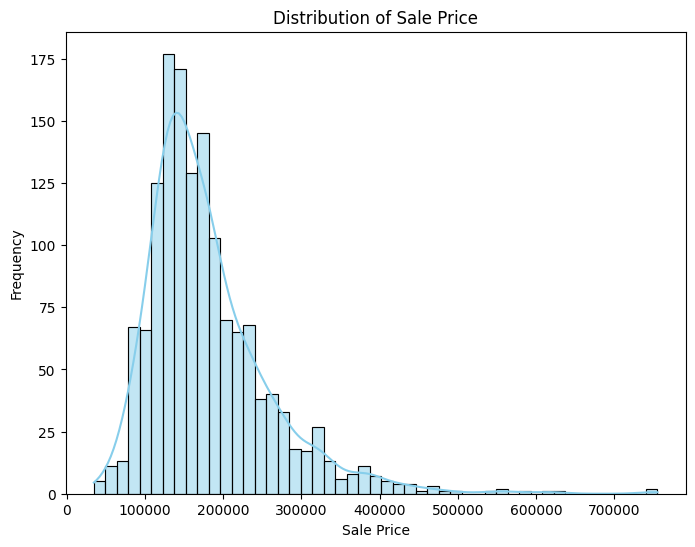

In [5]:
# Distribution of SalePrice
plt.figure(figsize=(8, 6))
sns.histplot(data['SalePrice'], kde=True, color='skyblue')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

We use a boxplot to compare the distribution of `SalePrice` across different categories. This helps identify how different groups (e.g., neighborhoods) affect house prices.

/var/folders/wp/6s93f1gn59scny_dhb9178x40000gn/T/ipykernel_12147/2497817035.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='SalePrice', data=data, palette='viridis')


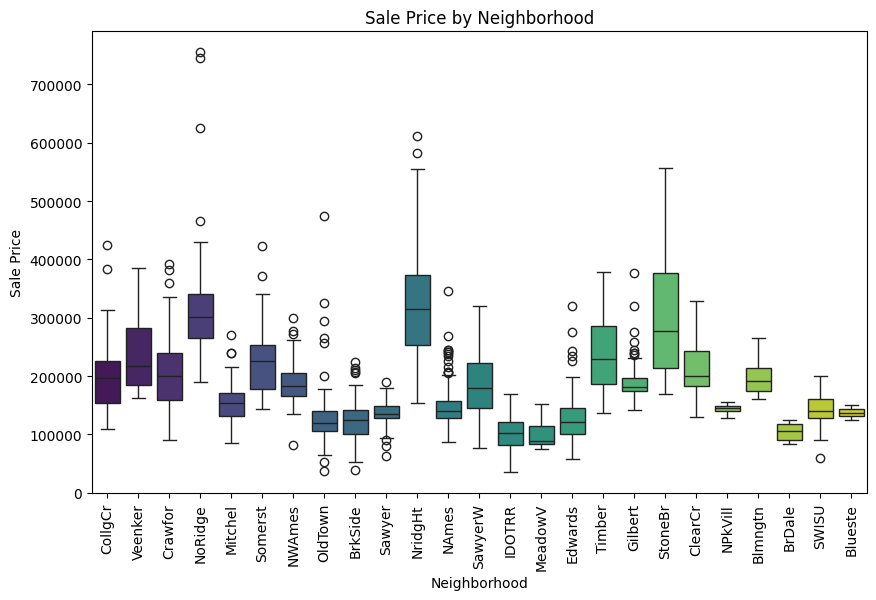

In [6]:
# Boxplot of SalePrice by Neighborhood
plt.figure(figsize=(10, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=data, palette='viridis')
plt.xticks(rotation=90)
plt.title('Sale Price by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Sale Price')
plt.show()

The heatmap shows the correlation between numerical features. This helps us understand which features are most strongly related to `SalePrice` and might be useful for modeling.

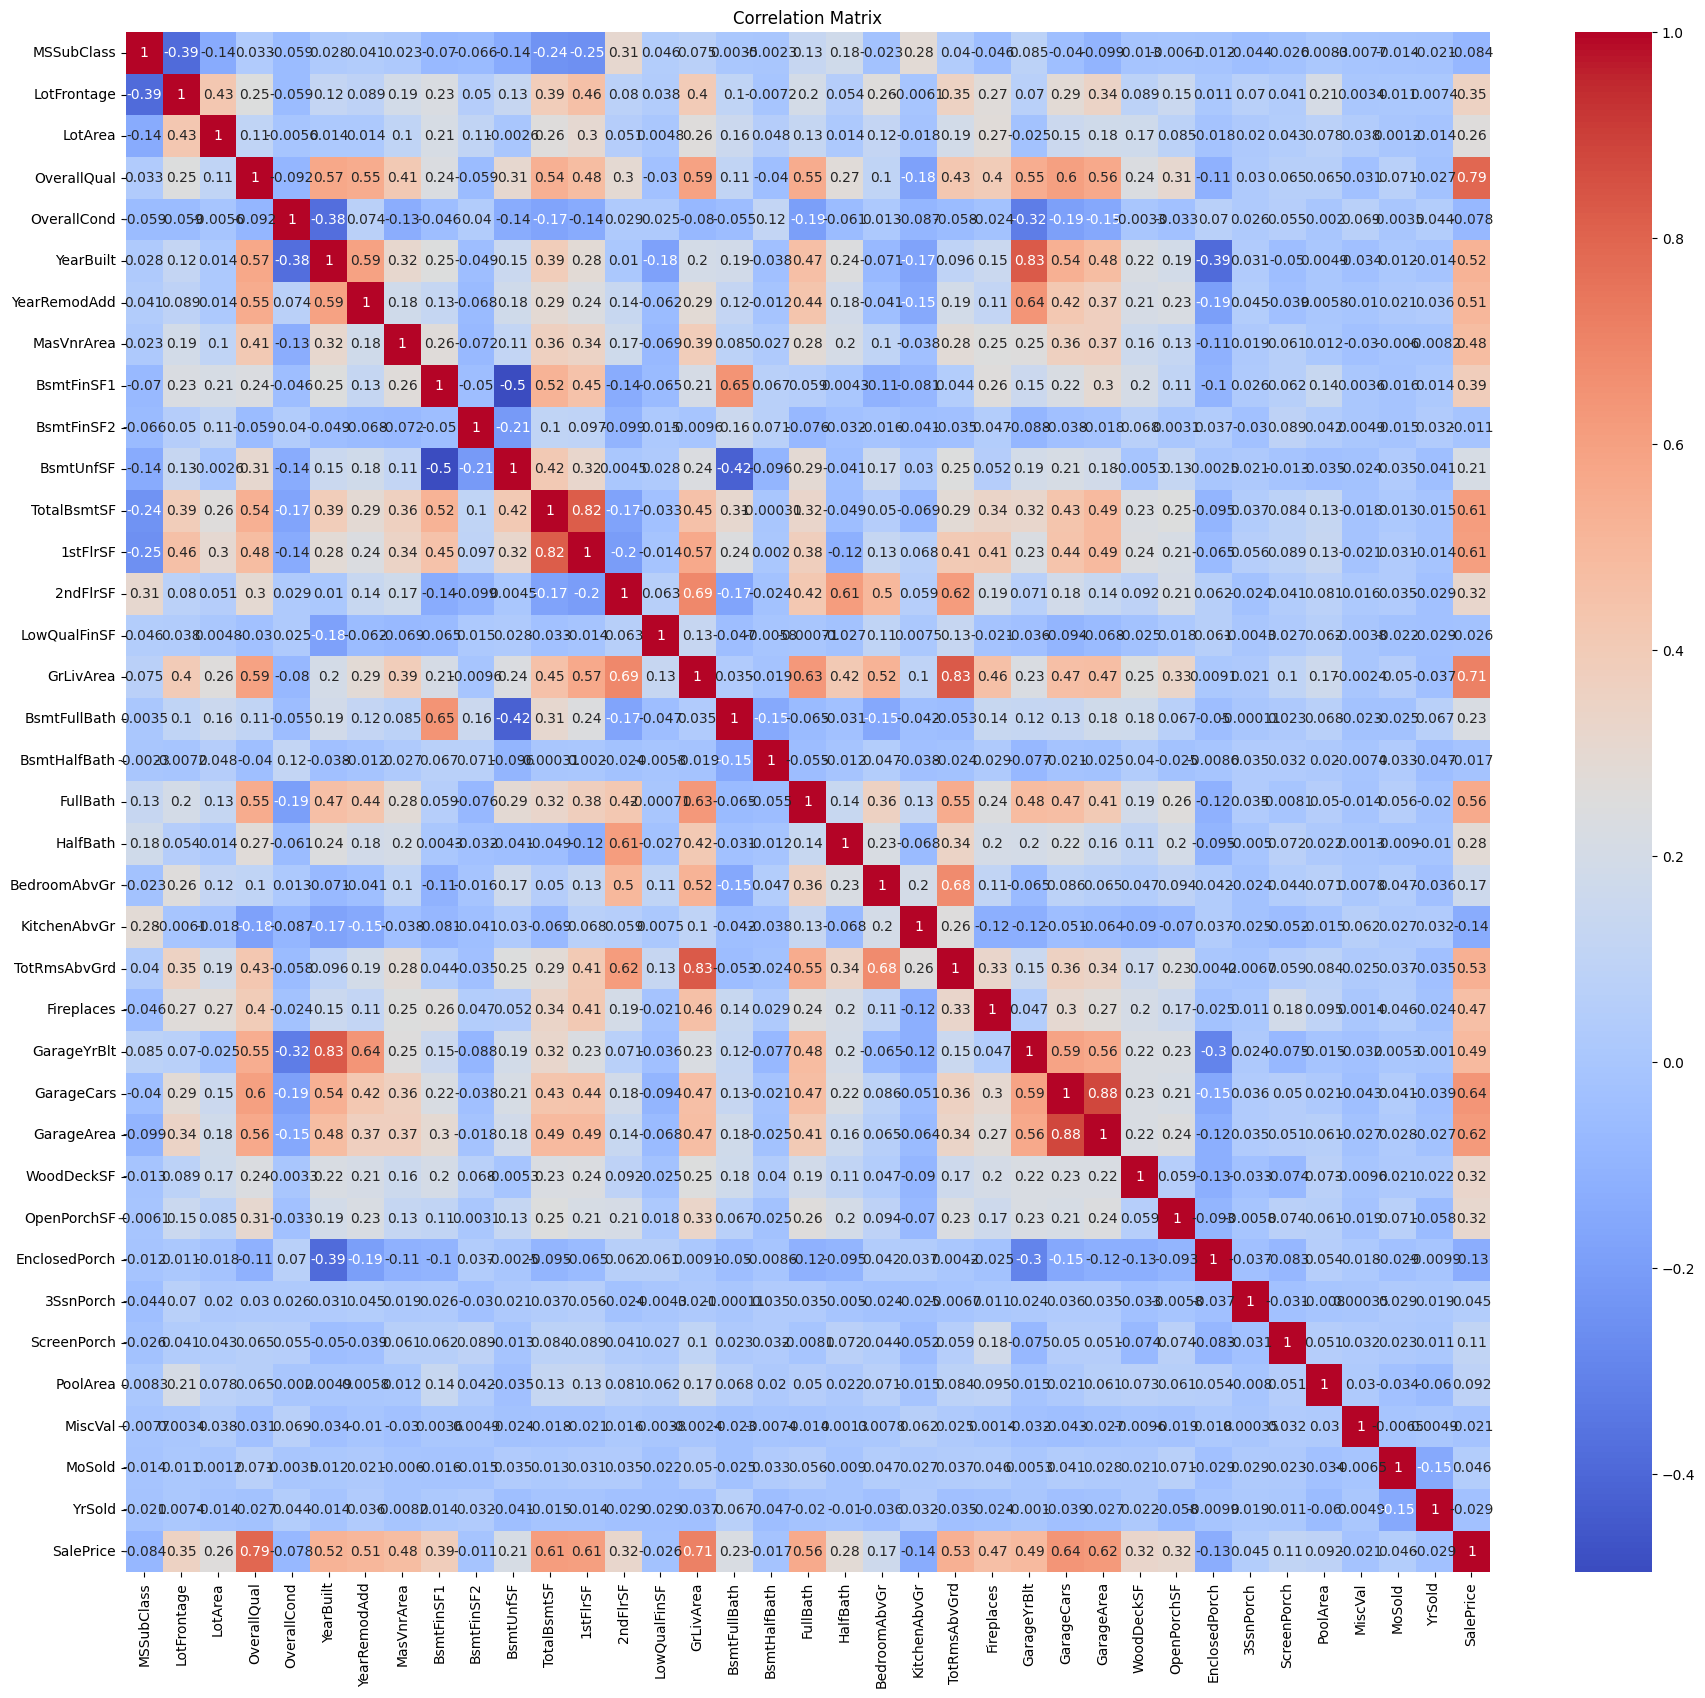

In [7]:

# Correlation Matrix
correlation = data.corr(numeric_only=True)
plt.figure(figsize=(22, 20))
sns.heatmap(correlation, annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

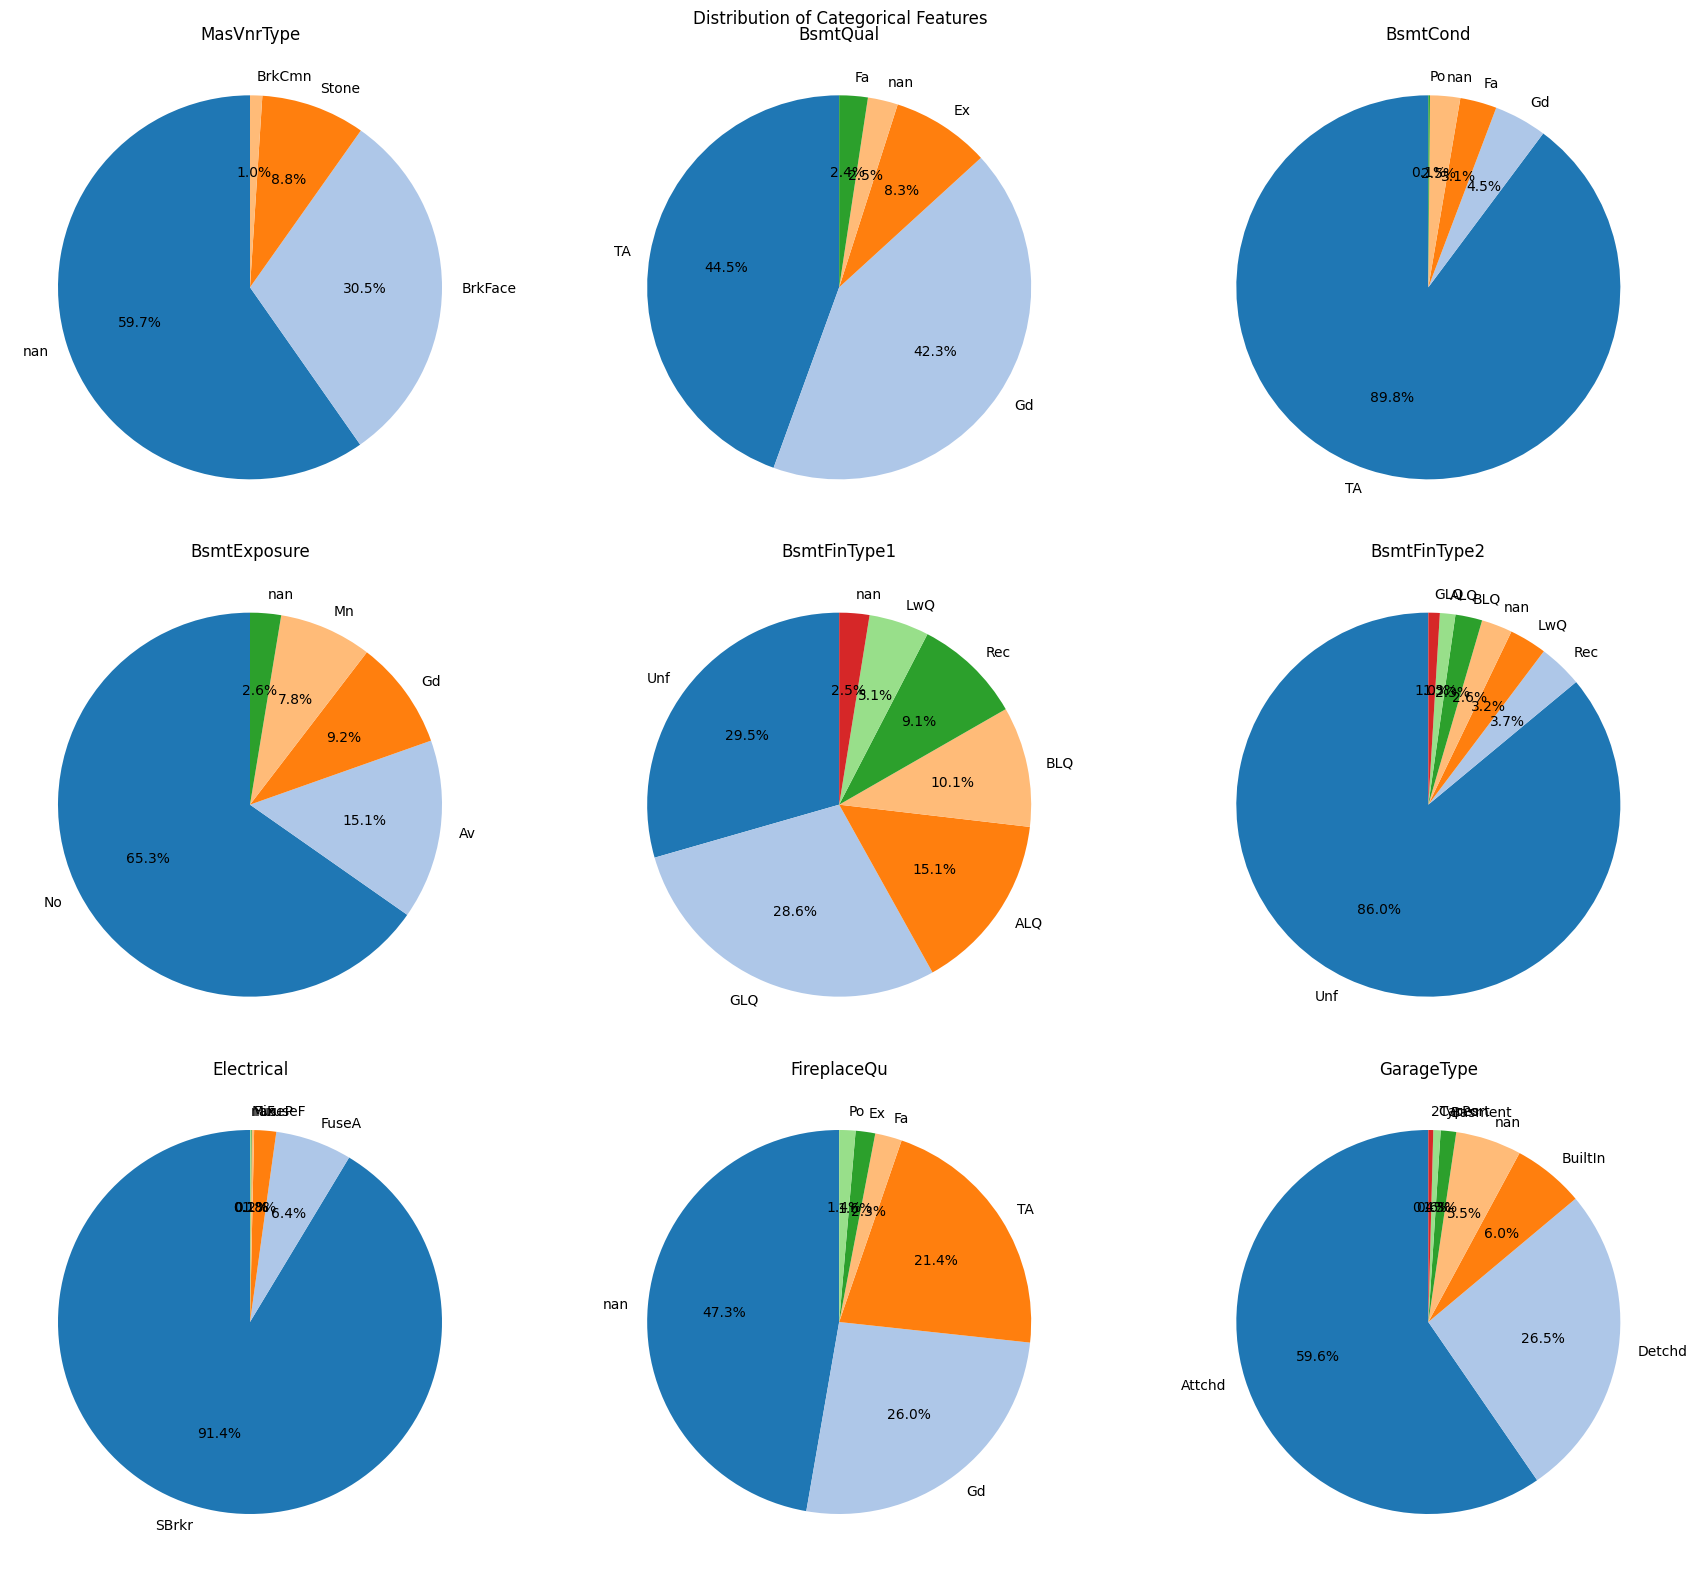

In [8]:

# Pie Charts for Categorical Features
categorical_columns = ['MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
                       'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType']

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    data[col].value_counts(dropna=False).plot.pie(
        autopct='%1.1f%%', 
        ax=axes[i], 
        legend=False, 
        startangle=90, 
        colors=plt.cm.tab20.colors
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('')

plt.suptitle('Distribution of Categorical Features', fontsize=12)
plt.tight_layout()
plt.show()

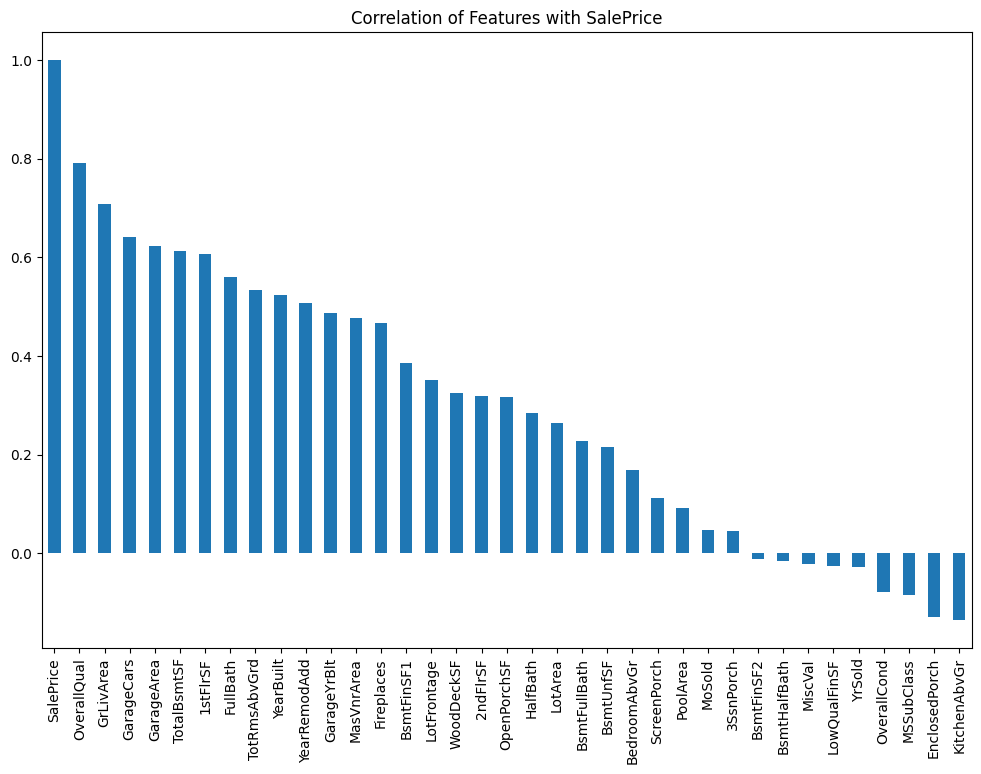

In [9]:
# Calculate correlation with SalePrice and sort
correlations = data.corr(numeric_only=True)['SalePrice'].dropna().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
correlations.plot(kind='bar')
plt.title('Correlation of Features with SalePrice')
plt.xticks(rotation=90)
plt.show()

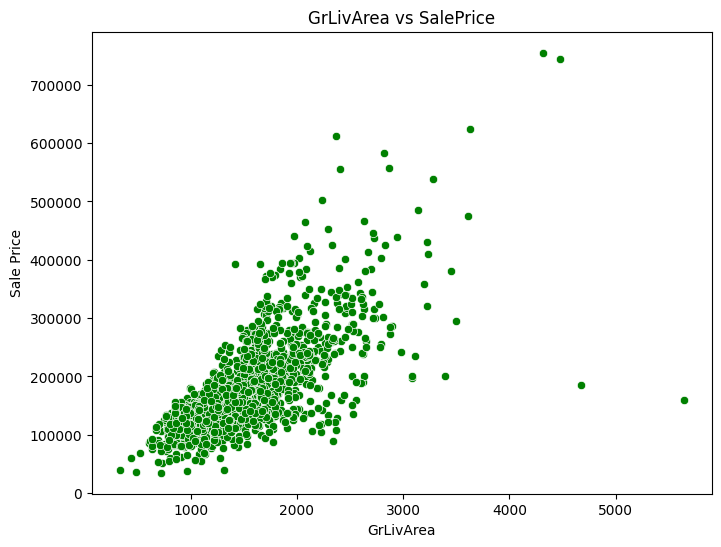

In [10]:
# Scatterplot of GrLivArea vs SalePrice
plt.figure(figsize=(8, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=data, color='green')
plt.title('GrLivArea vs SalePrice')
plt.xlabel('GrLivArea')
plt.ylabel('Sale Price')
plt.show()

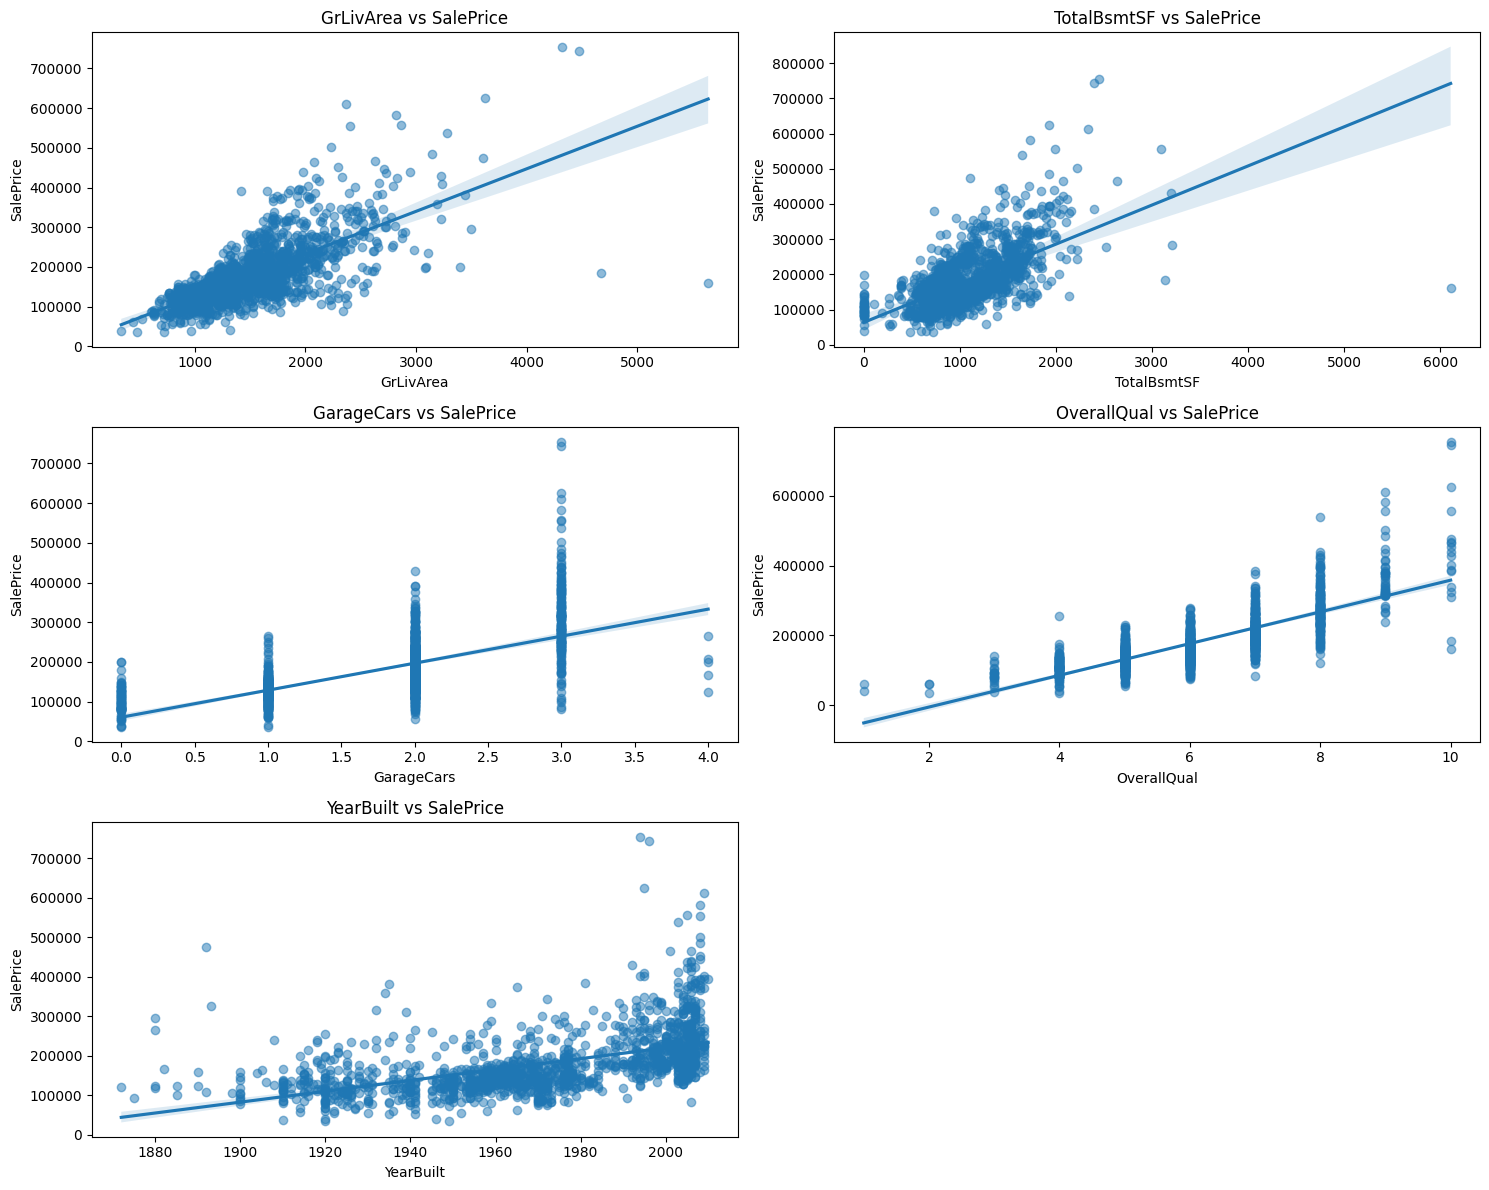

In [11]:
important_features = ['GrLivArea', 'TotalBsmtSF', 'GarageCars', 'OverallQual', 'YearBuilt']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(important_features, 1):
    plt.subplot(3, 2, i)
    sns.regplot(x=data[feature], y=data['SalePrice'], scatter_kws={'alpha':0.5})
    plt.title(f'{feature} vs SalePrice')
    plt.xlabel(feature)
    plt.ylabel('SalePrice')

plt.tight_layout()
plt.show()

/var/folders/wp/6s93f1gn59scny_dhb9178x40000gn/T/ipykernel_12147/3960582206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=data, palette='Blues')


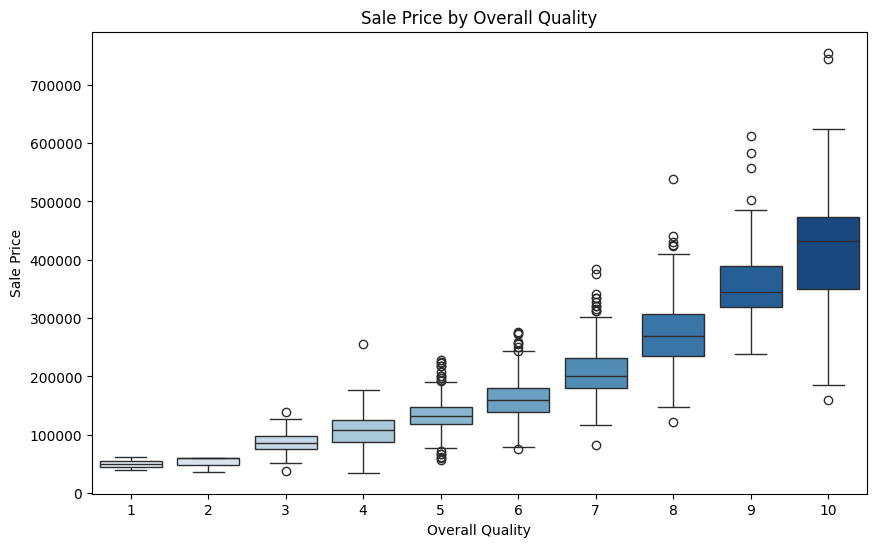

In [12]:
# Boxplot of SalePrice by Overall Quality
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=data, palette='Blues')
plt.title('Sale Price by Overall Quality')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price')
plt.show()

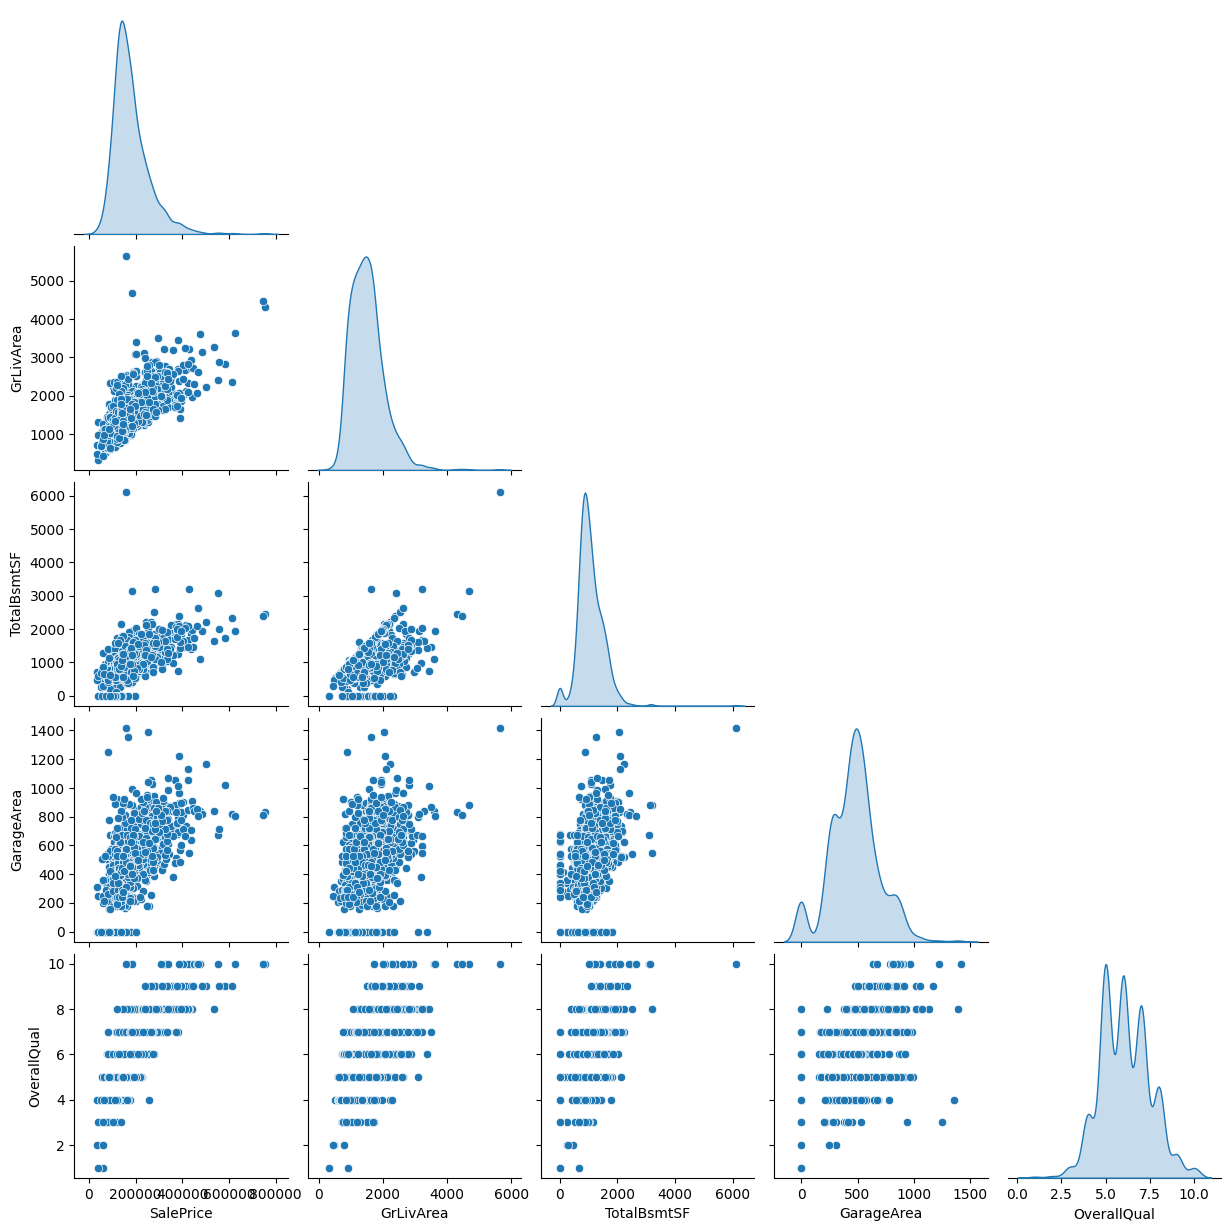

In [13]:
#Pair Plot of Important Numeric Features
important_features = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'GarageArea', 'OverallQual']
sns.pairplot(data[important_features], corner=True, diag_kind='kde')
plt.show()

## Handling Missing Values
We handle missing values by filling them with appropriate statistics like the median.

In addition, we preprocess the **categorical features** using **One-Hot Encoding**:

## Why We Applied Log Transformation to SalePrice
The `SalePrice` variable was log-transformed to reduce skewness and stabilize variance. This transformation helps the model perform better by making the target distribution more normal. This approach is widely used in similar machine learning tasks and Kaggle competitions.

In [14]:
# Feature Engineering and Handling Missing Values
# Log transformation of SalePrice
data['LogSalePrice'] = np.log1p(data['SalePrice'])

# Fill missing values (numeric: median, categorical: mode)
data.fillna(data.median(numeric_only=True), inplace=True)

# Identify numeric and categorical features
numeric_features = data.select_dtypes(include=['int64', 'float64']).columns
categorical_features = data.select_dtypes(include=['object']).columns

# Select features for modeling
target = 'LogSalePrice'
features = list(set(numeric_features) - {'SalePrice', 'LogSalePrice'})

# Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features),
        ('cat', categorical_transformer, categorical_features)
    ])

## Why We Did Not Drop Any Data
In this model, we chose not to drop any data because we believe that every piece of information can contribute to the learning process. Retaining all available features allows the model to capture more patterns and relationships within the data, potentially improving its predictive performance.

## Train Test Split

In [15]:
# Train-Test Split
X = data[features + list(categorical_features)]
y = data[target]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training 

In [16]:
# Linear Regression Model (Normal Equation)
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_train_pred_lr = lr_pipeline.predict(X_train)
y_val_pred_lr = lr_pipeline.predict(X_val)

In [17]:
# SGD Regressor Model
sgd_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDRegressor(max_iter=100000, tol=False, random_state=42))
])
sgd_pipeline.fit(X_train, y_train)
y_train_pred_sgd = sgd_pipeline.predict(X_train)
y_val_pred_sgd = sgd_pipeline.predict(X_val)

# Model Evaluation and Comparison
We evaluate the model's performance using metrics like Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score.

In [18]:
# Calculate metrics for Linear Regression
mse_train_lr = mean_squared_error(y_train, y_train_pred_lr)
mse_val_lr = mean_squared_error(y_val, y_val_pred_lr)
rmse_train_lr = np.sqrt(mse_train_lr)
rmse_val_lr = np.sqrt(mse_val_lr)
r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_val_lr = r2_score(y_val, y_val_pred_lr)

# Calculate metrics for SGD Regressor
mse_train_sgd = mean_squared_error(y_train, y_train_pred_sgd)
mse_val_sgd = mean_squared_error(y_val, y_val_pred_sgd)
rmse_train_sgd = np.sqrt(mse_train_sgd)
rmse_val_sgd = np.sqrt(mse_val_sgd)
r2_train_sgd = r2_score(y_train, y_train_pred_sgd)
r2_val_sgd = r2_score(y_val, y_val_pred_sgd)

# Compare Models
comparison_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'R²'],
    'Linear Regression (Train)': [mse_train_lr, rmse_train_lr, r2_train_lr],
    'Linear Regression (Validation)': [mse_val_lr, rmse_val_lr, r2_val_lr],
    'SGD Regressor (Train)': [mse_train_sgd, rmse_train_sgd, r2_train_sgd],
    'SGD Regressor (Validation)': [mse_val_sgd, rmse_val_sgd, r2_val_sgd]
})

print("\nModel Comparison:")
display(comparison_df.T)


Model Comparison:


,0,1,2
Metric,MSE,RMSE,R²
Linear Regression (Train),0.008396,0.09163,0.944923
Linear Regression (Validation),0.01746,0.132137,0.906435
SGD Regressor (Train),0.018383,0.135584,0.87941
SGD Regressor (Validation),0.026573,0.163011,0.857604


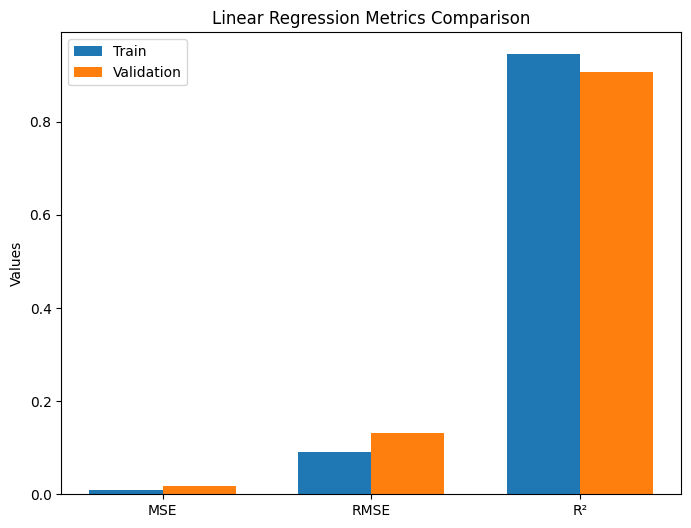

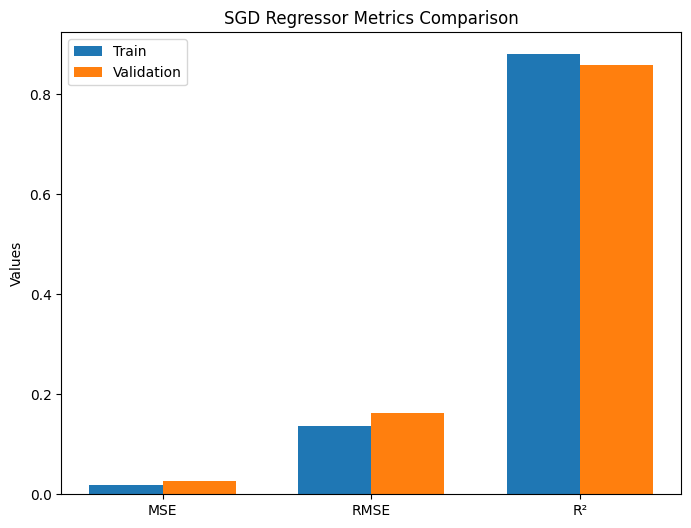

In [19]:
# Metrics to display
metrics = ['MSE', 'RMSE', 'R²']
x = np.arange(len(metrics))
width = 0.35

# Linear Regression Plot
plt.figure(figsize=(8, 6))
plt.bar(x - width/2, comparison_df['Linear Regression (Train)'], width, label='Train')
plt.bar(x + width/2, comparison_df['Linear Regression (Validation)'], width, label='Validation')
plt.title('Linear Regression Metrics Comparison')
plt.xticks(x, metrics)
plt.ylabel('Values')
plt.legend()
plt.show()

# SGD Regressor Plot
plt.figure(figsize=(8, 6))
plt.bar(x - width/2, comparison_df['SGD Regressor (Train)'], width, label='Train')
plt.bar(x + width/2, comparison_df['SGD Regressor (Validation)'], width, label='Validation')
plt.title('SGD Regressor Metrics Comparison')
plt.xticks(x, metrics)
plt.ylabel('Values')
plt.legend()
plt.show()

In [20]:
import plotly.graph_objects as go

# Metrics for plotting
linear_regression_train = [mse_train_lr, rmse_train_lr, r2_train_lr]
linear_regression_val = [mse_val_lr, rmse_val_lr, r2_val_lr]
sgd_train = [mse_train_sgd, rmse_train_sgd, r2_train_sgd]
sgd_val = [mse_val_sgd, rmse_val_sgd, r2_val_sgd]

# Create figure
fig = go.Figure()

# Add Linear Regression - Training
fig.add_trace(go.Scatter(
    x=metrics,
    y=linear_regression_train,
    mode='lines+markers',
    name='Linear Regression (Train)',
    line=dict(color='blue')
))

# Add Linear Regression - Validation
fig.add_trace(go.Scatter(
    x=metrics,
    y=linear_regression_val,
    mode='lines+markers',
    name='Linear Regression (Validation)',
    line=dict(color='blue', dash='dash')
))

# Add SGD - Training
fig.add_trace(go.Scatter(
    x=metrics,
    y=sgd_train,
    mode='lines+markers',
    name='SGD Regressor (Train)',
    line=dict(color='red')
))

# Add SGD - Validation
fig.add_trace(go.Scatter(
    x=metrics,
    y=sgd_val,
    mode='lines+markers',
    name='SGD Regressor (Validation)',
    line=dict(color='red', dash='dash')
))

# Customize layout
fig.update_layout(
    title='Comparison of Linear Regression and SGD Regressor Metrics',
    xaxis_title='Metrics',
    yaxis_title='Values',
    legend=dict(x=0, y=1.0),
    template='plotly_dark'
)

# Show plot
fig.show()

The Linear Regression model performs slightly better than the SGD Regressor across all metrics (MSE, RMSE, and R²) on both the training and validation datasets. 

The models show:

Low error values (MSE and RMSE), indicating accurate predictions.
High R² scores, meaning they explain a large portion of the variability in SalePrice.
Overall, both models generalize well to new data, but Linear Regression achieves more reliable and consistent performance with fewer errors compared to the SGD Regressor